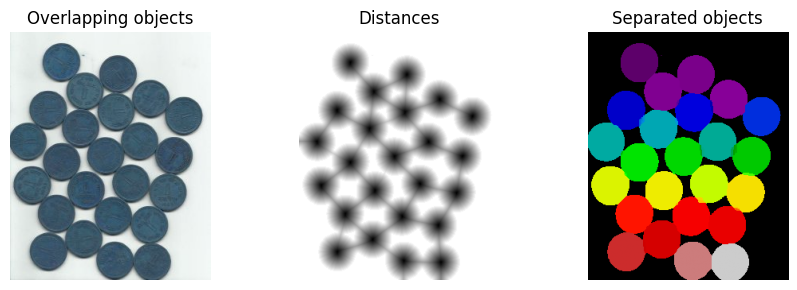

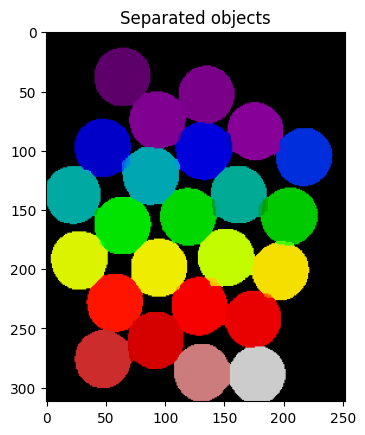

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage as ndi
import cv2
import os

from skimage.segmentation import watershed
from skimage.feature import peak_local_max

def showimage(image, title_=None, cmap_=None):
    plt.imshow(image, cmap=cmap_)
    plt.title(title_)

# Generate an initial image with two overlapping circles
x, y = np.indices((80, 80))
x1, y1, x2, y2 = 28, 28, 44, 52
r1, r2 = 16, 20
mask_circle1 = (x - x1) ** 2 + (y - y1) ** 2 < r1**2
mask_circle2 = (x - x2) ** 2 + (y - y2) ** 2 < r2**2
image_ = np.logical_or(mask_circle1, mask_circle2)

jpg_path = r"..\Watershed/Image/water_coins.jpg"
image = cv2.imread(jpg_path)

image_gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
ret, thresh = cv2.threshold(image_gray, 0, 255, cv2.THRESH_BINARY_INV+cv2.THRESH_OTSU)

# Now we want to separate the two objects in image
# Generate the markers as local maxima of the distance to the background
distance = ndi.distance_transform_edt(thresh)
coords = peak_local_max(distance, footprint=np.ones((3, 3)), labels=thresh)
mask = np.zeros(distance.shape, dtype=bool)
mask[tuple(coords.T)] = True
markers, _ = ndi.label(mask)

labels = watershed(-distance, markers, mask=thresh)

#markers_cv = cv2.watershed(image_cv, markers)

count = 3
fig, axes = plt.subplots(ncols=count, figsize=(count*3, count), sharex=True, sharey=True)
ax = axes.ravel()

ax[0].imshow(image, cmap=plt.cm.gray)
ax[0].set_title('Overlapping objects')
ax[1].imshow(-distance, cmap=plt.cm.gray)
ax[1].set_title('Distances')
ax[2].imshow(labels, cmap=plt.cm.nipy_spectral)
ax[2].set_title('Separated objects')
#ax[3].imshow(markers_cv, cmap=plt.cm.gray)
#ax[3].set_title('Separated objects for cv')


for a in ax:
    a.set_axis_off()

fig.tight_layout()
plt.show()
showimage(labels, 'Separated objects', plt.cm.nipy_spectral)